# CPU Version

In [5]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # optional, verhindert GPU-Attach
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.models import TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer

# 1) Daten laden (gleicher Pfad wie im Training)
df = pd.read_csv(
    r"dataset\2 - data second model\load_and_weather_2024-01-01_2026-02-28_cleaned.csv",
    parse_dates=True
)

# --- nur das Nötigste für den Sanity-Check ---
df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")
df["load_15min"] = pd.to_numeric(df["load_15min"], errors="coerce")
df = df.sort_values("date_time").reset_index(drop=True)

# time_idx + group
df["time_idx"] = ((df["date_time"] - df["date_time"].min()).dt.total_seconds() // (15*60)).astype(int)
df["series_id"] = "load"

# bekannte/ unbekannte Reals (mindestens target + ein paar deiner Spalten, hier exemplarisch)
known_reals = [c for c in df.columns if c in {
    "hour_sin","hour_cos","minute_sin","minute_cos",
    "month_sin","month_cos","weekday_sin","weekday_cos",
    "weekend","early_shift","late_shift","night_shift",
    "shiftchange_el","shiftchange_ln","shiftchange_ne",
    "holiday","bridging_day","temp","rel_humidity","wind","radiation","precip","clouds",
    "rolling_temp_3h","rolling_rel_humidity_3h","rolling_wind_3h","rolling_radiation_3h","rolling_precip_3h","rolling_clouds_3h",
    "temp_lag1h","temp_lag3h","temp_lag6h","temp_lag24h",
    "rel_humidity_lag1h","rel_humidity_lag3h","rel_humidity_lag6h","rel_humidity_lag24h",
    "wind_lag1h","wind_lag3h","wind_lag6h","wind_lag24h",
    "radiation_lag1h","radiation_lag3h","radiation_lag6h","radiation_lag24h",
    "precip_lag1h","precip_lag3h","precip_lag6h","precip_lag24h",
    "clouds_lag1h","clouds_lag3h","clouds_lag6h","clouds_lag24h",
    "hdd_quarterly","cdd_quarterly","wet_bulb","rolling_wet_bulb_3h",
    "wet_bulb_lag1h","wet_bulb_lag3h","wet_bulb_lag6h","wet_bulb_lag24h"
}]
observed_reals = [c for c in df.columns if c in {
    "load_15min","load_1h_ago","load_2h_ago","load_24h_ago","load_168h_ago",
    "rolling_mean_3h","rolling_mean_6h","rolling_mean_12h",
    "rolling_std_3h","rolling_std_6h","rolling_std_12h"
}]

STEPS = 4
HORIZON = 24
max_pred_len = HORIZON * STEPS
max_enc_len  = 7 * 24 * STEPS
val_days = 60

cutoff_time = df["date_time"].max() - pd.Timedelta(days=val_days)
cutoff_idx  = df.loc[df["date_time"] <= cutoff_time, "time_idx"].max()

training = TimeSeriesDataSet(
    df[df["time_idx"] <= cutoff_idx],
    time_idx="time_idx",
    target="load_15min",
    group_ids=["series_id"],
    max_encoder_length=max_enc_len,
    max_prediction_length=max_pred_len,
    time_varying_known_reals=known_reals,
    time_varying_unknown_reals=observed_reals,
    target_normalizer=GroupNormalizer(groups=["series_id"]),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    df,
    min_prediction_idx=cutoff_idx + 1,
    stop_randomization=True
)

val_loader = validation.to_dataloader(batch_size=64, shuffle=False, num_workers=0)

# 2) Modell CPU-sicher laden
best_path = r"lightning_logs\version_18\checkpoints\tft-best-epoch=00-val_MAE=849.6180.ckpt"
tft_model = TemporalFusionTransformer.load_from_checkpoint(
    best_path,
    map_location="cpu",     # <— zwingt CPU
    strict=False,
    weights_only=False       # <— Wichtig
)
tft_model.eval()

# 3) CPU-Prediction (ohne trainer_kwargs)
raw_pred = tft_model.predict(val_loader, mode="raw")  # CPU
pred_np   = raw_pred["prediction"].squeeze().detach().cpu().numpy()   # (N,96,Q) oder (N,96) je nach Loss

# 4) Median-Quantil (falls QuantileLoss)
yhat = pred_np
if yhat.ndim == 3:
    quants = list(getattr(tft_model.loss, "quantiles", [0.5]))
    if 0.5 in quants:
        yhat = yhat[:, :, quants.index(0.5)]
    else:
        # Fallback: mittleres Quantil nehmen
        yhat = yhat[:, :, len(quants)//2]

print("CPU yhat shape:", yhat.shape)  # erwartet: (N, 96)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


CPU yhat shape: (5665, 96)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Starte Baseline-Inferenz...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


[Hinweis] y_true(5632) != yhat(5665) -> Trimme auf 5632
Baseline y_true shape: (5632, 96) | yhat shape: (5632, 96)
Baseline MAE: 773.660 | Baseline RMSE: 979.263
y_true percentiles: [ 9120. 11800. 13670.]
yhat  percentiles: [ 9957.80327148 11582.73730469 12504.94996094]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


...

[Hinweis] y_true(1152) != yhat(1249) -> Trimme auf 1152
[PFI] temp_lag24h: ΔMAE = -10.492259 | Dauer 0.63 min

Permutiere Feature: rolling_temp_3h


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


[Hinweis] y_true(1152) != yhat(1249) -> Trimme auf 1152
[PFI] rolling_temp_3h: ΔMAE = -7.461414 | Dauer 0.62 min

Permutiere Feature: wet_bulb_lag1h


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


[Hinweis] y_true(1152) != yhat(1249) -> Trimme auf 1152
[PFI] wet_bulb_lag1h: ΔMAE = -6.438433 | Dauer 0.62 min

Top-10 PFI:
              feature  importance    mae_perm
16          wet_bulb   20.786529  793.316217
11      rel_humidity   15.132538  787.662225
21        temp_lag6h   13.835461  786.365149
19        temp_lag1h    4.540895  777.070583
6   rolling_mean_12h    1.511245  774.040933
1        load_2h_ago    0.402485  772.932173
7     rolling_std_3h    0.367302  772.896990
5    rolling_mean_6h    0.319459  772.849146
4    rolling_mean_3h    0.319121  772.848809
9    rolling_std_12h    0.164055  772.693743


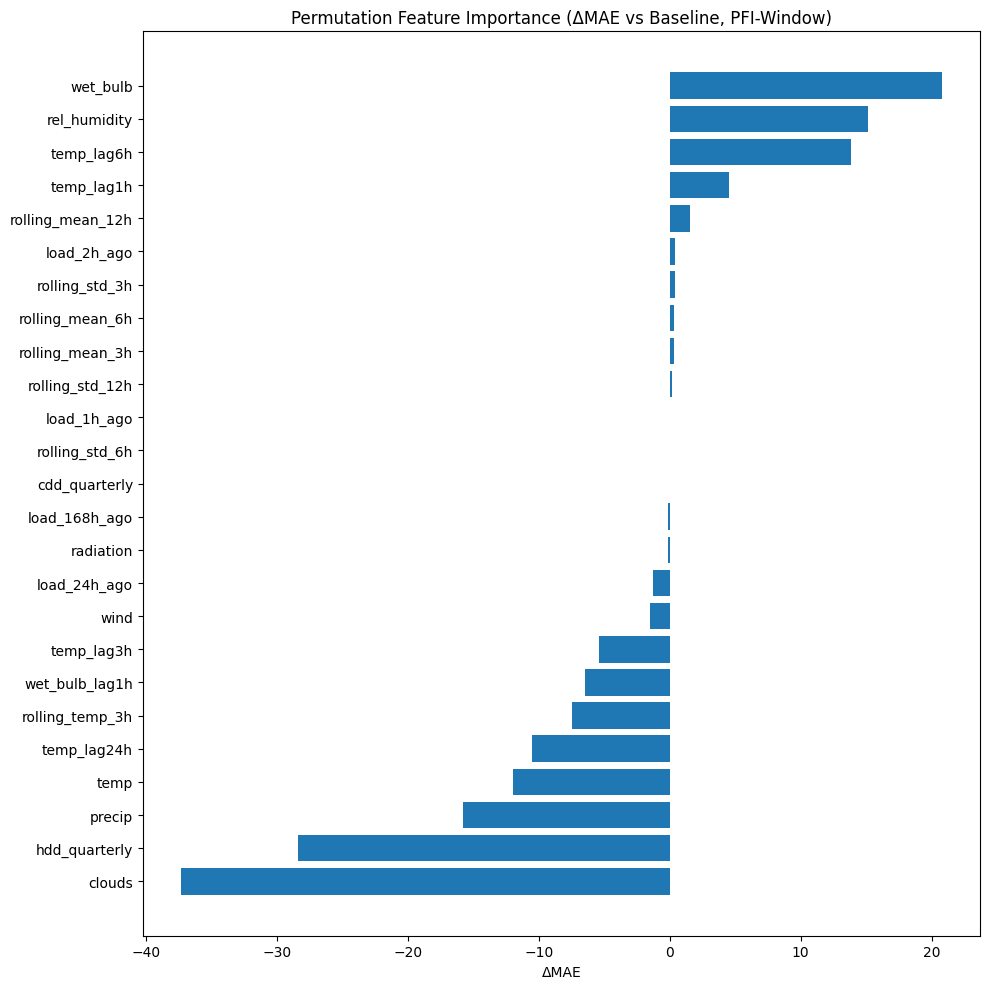

ModuleNotFoundError: No module named 'pytorch_forecasting.visualization'

In [ ]:
# ============================================================
# 5) Baseline-Inferenz + Ground Truth aus *demselben* Pass
#    -> speichersparend (prediction-mode), korrekt normalisiert
# ============================================================

import numpy as np
import gc
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import time
import torch

def infer_and_collect(loader, model, max_pred_len, loss):
    """Speichersparende Inferenz: nutzt mode='prediction' + no_grad."""
    with torch.no_grad():
        pred = model.predict(loader, mode="prediction")  # (N,96) oder (N,96,Q)

    # Median-Quantil, falls vorhanden
    if isinstance(pred, torch.Tensor):
        pred = pred.detach().cpu().numpy()
    else:
        # falls numpy
        pred = np.asarray(pred)

    if pred.ndim == 3:
        quants = list(getattr(loss, "quantiles", [0.5]))
        yhat = pred[:, :, quants.index(0.5)] if 0.5 in quants else pred[:, :, len(quants)//2]
    else:
        yhat = pred

    # Ground truth zu denselben Batches
    y_list = []
    for batch in loader:
        y_part = batch[1]
        if isinstance(y_part, (tuple, list)):
            tgt = y_part[0]
        else:
            tgt = y_part
        if hasattr(tgt, "ndim") and tgt.ndim == 3 and tgt.size(-1) == 1:
            tgt = tgt.squeeze(-1)
        y_list.append(tgt[:, -max_pred_len:])

    y_true = torch.cat(y_list).detach().cpu().numpy()

    # Safe Align
    n = min(len(y_true), len(yhat))
    if len(y_true) != len(yhat):
        print(f"[Hinweis] y_true({len(y_true)}) != yhat({len(yhat)}) -> Trimme auf {n}")
    y_true = y_true[:n]
    yhat = yhat[:n]

    mae = mean_absolute_error(y_true.reshape(-1), yhat.reshape(-1))
    rmse = np.sqrt(mean_squared_error(y_true.reshape(-1), yhat.reshape(-1)))
    return y_true, yhat, mae, rmse

print("Starte Baseline-Inferenz...")
y_true, yhat, mae_base, rmse_base = infer_and_collect(val_loader, tft_model, max_pred_len, tft_model.loss)
print(f"Baseline y_true shape: {y_true.shape} | yhat shape: {yhat.shape}")
print(f"Baseline MAE: {mae_base:.3f} | Baseline RMSE: {rmse_base:.3f}")

# Sanity-Check auf Skalen (sollten ähnliche Größenordnung haben)
print("y_true percentiles:", np.percentile(y_true, [1, 50, 99]))
print("yhat  percentiles:", np.percentile(yhat,  [1, 50, 99]))


# ============================================================
# 6) PFI – speichersicher + schneller (optional kleineres Val-Fenster)
# ============================================================

from copy import deepcopy

# Optional: kleineres Val-Fenster nur für PFI (beschleunigt & stabilisiert)
PFI_DAYS = 14  # z.B. 14 Tage statt 60
pfi_cutoff_time = df["date_time"].max() - pd.Timedelta(days=PFI_DAYS)
pfi_cutoff_idx  = df.loc[df["date_time"] <= pfi_cutoff_time, "time_idx"].max()

validation_pfi = TimeSeriesDataSet.from_dataset(
    training,
    df,
    min_prediction_idx=pfi_cutoff_idx + 1,
    stop_randomization=True,
)
val_loader_pfi = validation_pfi.to_dataloader(batch_size=128, shuffle=False, num_workers=0)

# Baseline nur für PFI-Fenster (damit ΔMAE vergleichbar ist)
y_true_pfi, yhat_pfi, mae_base_pfi, _ = infer_and_collect(val_loader_pfi, tft_model, max_pred_len, tft_model.loss)
print(f"[PFI-Window] Baseline MAE: {mae_base_pfi:.3f} | N={len(y_true_pfi)}")

# Feature-Auswahl begrenzen (RAM/Laufzeit)
PFI_TOP_K = 25
all_features = list(dict.fromkeys(observed_reals + known_reals))
exclude = {"load_15min", "time_idx", "date_time", "series_id"}
pfi_features = [f for f in all_features if f not in exclude][:PFI_TOP_K]
print(f"PFI über {len(pfi_features)} Features:", pfi_features)

def make_val_loader_from_df(df_new, batch_size=128):
    validation_perm = TimeSeriesDataSet.from_dataset(
        training,
        df_new,
        min_prediction_idx=pfi_cutoff_idx + 1,
        stop_randomization=True,
    )
    return validation_perm.to_dataloader(batch_size=batch_size, shuffle=False, num_workers=0)

val_mask_pfi = df["time_idx"] > pfi_cutoff_idx
rng = np.random.default_rng(42)
pfi_rows = []

for feat in pfi_features:
    start = time.time()
    print(f"\nPermutiere Feature: {feat}")

    # 1) Kopie & Permutation im PFI-Fenster
    df_perm = df.copy(deep=True)
    vals = df_perm.loc[val_mask_pfi, feat].to_numpy().copy()
    rng.shuffle(vals)
    df_perm.loc[val_mask_pfi, feat] = vals

    # 2) Loader
    loader_perm = make_val_loader_from_df(df_perm, batch_size=128)

    # 3) Inferenz (prediction-mode, no_grad)
    yt_p, yh_p, mae_perm, _ = infer_and_collect(loader_perm, tft_model, max_pred_len, tft_model.loss)

    # 4) ΔMAE
    importance = mae_perm - mae_base_pfi
    pfi_rows.append({"feature": feat, "importance": float(importance), "mae_perm": float(mae_perm)})

    # 5) Speicher freigeben
    del df_perm, loader_perm, yt_p, yh_p
    gc.collect()

    dur = (time.time() - start) / 60
    print(f"[PFI] {feat}: ΔMAE = {importance:.6f} | Dauer {dur:.2f} min")

pfi_df = pd.DataFrame(pfi_rows).sort_values("importance", ascending=False)
print("\nTop-10 PFI:\n", pfi_df.head(10))


# ============================================================
# 7) PFI-Plot
# ============================================================

plt.figure(figsize=(10, max(6, 0.4*len(pfi_df))))
plt.barh(pfi_df["feature"], pfi_df["importance"])
plt.gca().invert_yaxis()
plt.title("Permutation Feature Importance (ΔMAE vs Baseline, PFI-Window)")
plt.xlabel("ΔMAE")
plt.tight_layout()
plt.show()



In [8]:
# ============================================================
# 8) TFT-Interpretation (version-agnostisch, ohne visualization-Modul)
#     WICHTIG: interpret_output bekommt NUR das raw_predictions-DICT!
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

print("Berechne TFT-Interpretation (version-agnostisch)...")
with torch.no_grad():
    raw_for_viz = tft_model.predict(val_loader_pfi, mode="raw", return_x=True)

# raw_for_viz ist (raw_predictions_dict, x) ODER nur dict – sauber entpacken:
if isinstance(raw_for_viz, (tuple, list)) and len(raw_for_viz) >= 1:
    raw_predictions = raw_for_viz[0]  # <- nur das DICT weitergeben!
else:
    raw_predictions = raw_for_viz

# Jetzt korrekt interpretieren
interpretation = tft_model.interpret_output(raw_predictions, reduction="sum")
print("Interpretation keys:", list(interpretation.keys()))

def _to_series(obj):
    """
    Versucht, eine sinnvolle Series (name->importance) aus unterschiedlichen
    Strukturen zu gewinnen (Series, DataFrame, dict, array).
    """
    if obj is None:
        return None
    if isinstance(obj, pd.Series):
        return obj
    if isinstance(obj, pd.DataFrame):
        if "importance" in obj.columns:
            s = obj["importance"]
            s.index = obj.index if obj.index.size == s.size else s.index
            return s
        if obj.shape[1] == 1:
            s = obj.iloc[:, 0]
            if s.name is None:
                s.name = "importance"
            return s
        return obj.sum(axis=1)
    if isinstance(obj, dict):
        try:
            return pd.Series(obj, dtype=float)
        except Exception:
            return pd.Series(obj)
    return None  # arrays ohne Namen sind nicht mappbar

# Mögliche Schlüssel je nach Version
enc_keys = ["encoder_variable_importance", "encoder_variables"]
dec_keys = ["decoder_variable_importance", "decoder_variables"]
sta_keys = ["static_variable_importance", "static_variables"]

enc_imp = next(( _to_series(interpretation[k]) for k in enc_keys if k in interpretation ), None)
dec_imp = next(( _to_series(interpretation[k]) for k in dec_keys if k in interpretation ), None)
sta_imp = next(( _to_series(interpretation[k]) for k in sta_keys if k in interpretation ), None)

def _barh_series(s: pd.Series, title: str):
    if s is None or len(s) == 0:
        print(f"[Info] Keine Daten für: {title}")
        return
    s = s.astype(float)
    s = s.replace([np.inf, -np.inf], np.nan).dropna()
    s = s.sort_values()
    plt.figure(figsize=(8, max(4, 0.35 * len(s))))
    plt.barh(s.index, s.values)
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

_barh_series(enc_imp, "Encoder Variable Importance (VSN)")
_barh_series(dec_imp, "Decoder Variable Importance (VSN)")
_barh_series(sta_imp, "Static Variable Importance (VSN)")

# Optionaler Fallback: falls es in deiner Version DOCH einen Sammel-Plot gibt
try:
    from pytorch_forecasting.visualization import plot_interpretation  # evtl. nicht vorhanden
    fig = plot_interpretation(interpretation)
    plt.show()
except Exception as e:
    print("[Info] plot_interpretation nicht verfügbar oder fehlgeschlagen:", str(e))


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Berechne TFT-Interpretation (version-agnostisch)...
Interpretation keys: ['attention', 'static_variables', 'encoder_variables', 'decoder_variables', 'encoder_length_histogram', 'decoder_length_histogram']
[Info] Keine Daten für: Encoder Variable Importance (VSN)
[Info] Keine Daten für: Decoder Variable Importance (VSN)
[Info] Keine Daten für: Static Variable Importance (VSN)
[Info] plot_interpretation nicht verfügbar oder fehlgeschlagen: No module named 'pytorch_forecasting.visualization'


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Berechne Interpretation (nur vorhandene Keys)...
Interpretation keys: ['attention', 'static_variables', 'encoder_variables', 'decoder_variables', 'encoder_length_histogram', 'decoder_length_histogram']


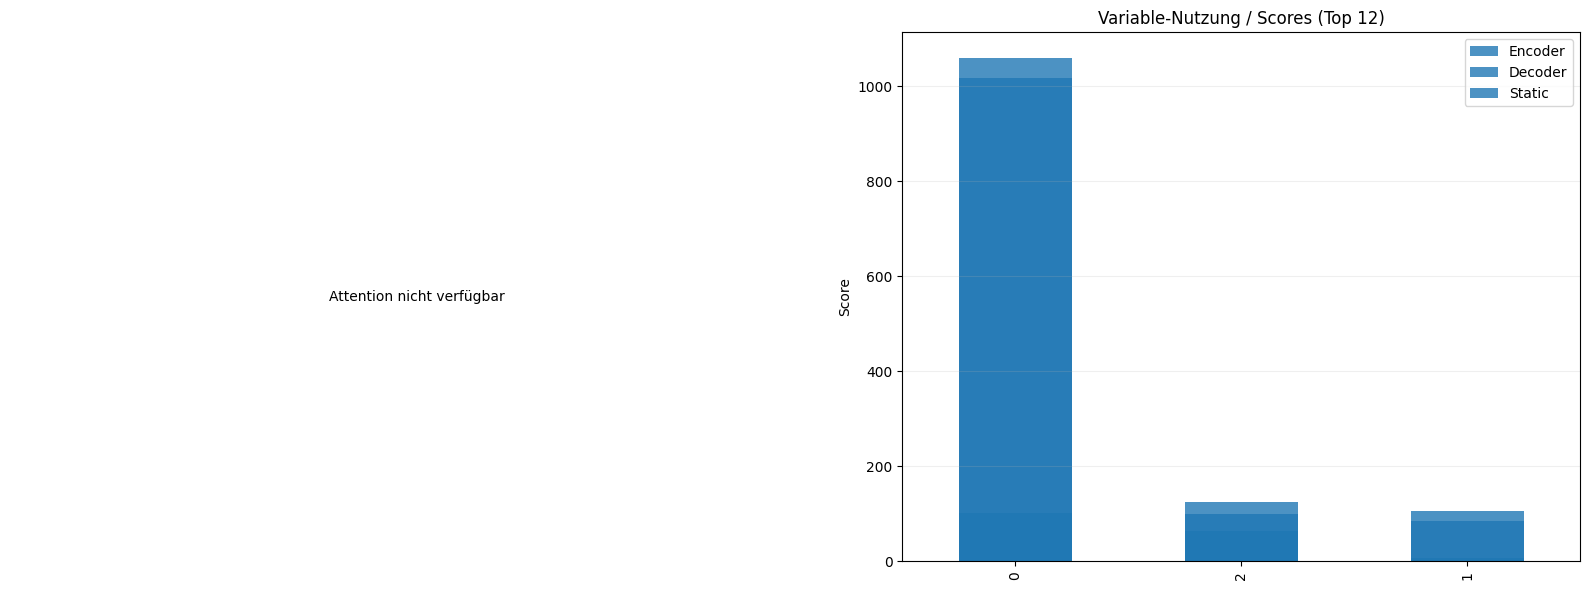

In [9]:
# ============================================================
# Option A: Attention-Heatmap + Variable-"Usage" (versionssicher np# Option A: Attention-Heatmap + Variable-"Usage" (versionssicher, keine Extra-Installs)
import pandas as pd
import matplotlib.pyplot as plt
import torch

# -------- 1) Raw-Predictions für Interpretation holen (raw + return_x=True)
print("Berechne Interpretation (nur vorhandene Keys)...")
with torch.no_grad():
    raw_for_viz = tft_model.predict(val_loader_pfi, mode="raw", return_x=True)

# raw_for_viz kann (dict, x) sein oder nur dict -> robust entpacken
if isinstance(raw_for_viz, (tuple, list)) and len(raw_for_viz) >= 1:
    raw_pred = raw_for_viz[0]
else:
    raw_pred = raw_for_viz

interpretation = tft_model.interpret_output(raw_pred, reduction="sum")
print("Interpretation keys:", list(interpretation.keys()))

# -------- 2) Helper: auf vorhandene Keys zugreifen
def get_interpretation(key_names):
    for k in key_names:
        if k in interpretation:
            return interpretation[k]
    return None

# Deine Version liefert laut Output u.a.:
attn = get_interpretation(["attention"])                # meist Liste/Tensor (B, H, T_dec, T_enc)
enc_vars = get_interpretation(["encoder_variables"])    # dict/array/df je nach Version
dec_vars = get_interpretation(["decoder_variables"])
stat_vars = get_interpretation(["static_variables"])

# -------- 3) Attention zu einer 2D-Heatmap reduzieren (T_dec x T_enc)
def reduce_attention(attn_obj):
    """
    Erwartete Formen:
      - Tensor/ndarray mit (B, H, T_dec, T_enc)
      - Liste/Tuple solcher Arrays
    Wir mitteln über Batch & Heads -> 2D Heatmap (T_dec x T_enc).
    """
    if attn_obj is None:
        return None
    try:
        a = attn_obj
        # ggf. Liste -> stapeln
        if isinstance(a, (list, tuple)):
            a = [np.asarray(x) for x in a]
            # Unterschiedliche Shapes auf max-pad ausgleichen
            max_dec = max(x.shape[-2] for x in a)
            max_enc = max(x.shape[-1] for x in a)
            padded = []
            for x in a:
                x = np.asarray(x)
                while x.ndim < 2:
                    x = np.expand_dims(x, 0)
                T_dec, T_enc = x.shape[-2], x.shape[-1]
                pad_dec = max_dec - T_dec
                pad_enc = max_enc - T_enc
                if pad_dec > 0 or pad_enc > 0:
                    x = np.pad(x, [(0,0)]*(x.ndim-2) + [(0,pad_dec), (0,pad_enc)], mode="constant")
                padded.append(x)
            a = np.stack(padded, axis=0)  # (L, ..., T_dec, T_enc)

        a = np.asarray(a)
        # Mittel über alle bis auf die letzten 2 Dims
        while a.ndim > 2:
            a = a.mean(axis=0)
        # jetzt 2D (T_dec x T_enc)
        return a
    except Exception as e:
        print("[Info] Konnte Attention nicht reduzieren:", str(e))
        return None

attn_map = reduce_attention(attn)

# -------- 4) Variable-"Usage" in Series wandeln, falls vorhanden
def to_series(obj, title=None):
    """Dict/Series/DataFrame/1D-Array -> Series (ansonsten None)."""
    if obj is None:
        return None
    if isinstance(obj, pd.Series):
        return obj.astype(float)
    if isinstance(obj, dict):
        try:
            return pd.Series({k: float(v) for k, v in obj.items()})
        except Exception:
            return pd.Series(obj)
    if isinstance(obj, pd.DataFrame):
        # Summe je Feature als konservativer Default
        if obj.shape[1] > 1:
            return obj.sum(axis=1)
        s = obj.iloc[:, 0]
        s.name = s.name or (title or "value")
        return s.astype(float)
    arr = np.asarray(obj)
    if arr.ndim == 1 and arr.size > 0 and arr.size <= 200:
        return pd.Series(arr, name=title or "value")
    return None

enc_usage = to_series(enc_vars, "encoder_usage")
dec_usage = to_series(dec_vars, "decoder_usage")
stat_usage = to_series(stat_vars, "static_usage")

# -------- 5) PLOTTEN
fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1.2, 1])

# (A) Attention-Heatmap
ax1 = fig.add_subplot(gs[0, 0])
if attn_map is not None and attn_map.ndim == 2 and attn_map.size > 0:
    im = ax1.imshow(attn_map, aspect="auto", cmap="viridis")
    ax1.set_title("Decoder→Encoder Attention (gemittelt)")
    ax1.set_xlabel("Encoder Time (Vergangenheit)")
    ax1.set_ylabel("Decoder Time (Zukunft)")
    cbar = fig.colorbar(im, ax=ax1, shrink=0.8)
    cbar.set_label("Attention")
else:
    ax1.text(0.5, 0.5, "Attention nicht verfügbar", ha="center", va="center")
    ax1.axis("off")

# (B) Variable-"Usage" (Top 12 je Typ, wenn vorhanden)
ax2 = fig.add_subplot(gs[0, 1])
bars_plotted = False
if isinstance(enc_usage, pd.Series) and len(enc_usage) > 0:
    enc_usage.sort_values(ascending=False).head(12).plot(kind="bar", ax=ax2, alpha=0.8, label="Encoder")
    bars_plotted = True
if isinstance(dec_usage, pd.Series) and len(dec_usage) > 0:
    dec_usage.sort_values(ascending=False).head(12).plot(kind="bar", ax=ax2, alpha=0.8, label="Decoder")
    bars_plotted = True
if isinstance(stat_usage, pd.Series) and len(stat_usage) > 0:
    stat_usage.sort_values(ascending=False).head(12).plot(kind="bar", ax=ax2, alpha=0.8, label="Static")
    bars_plotted = True

if bars_plotted:
    ax2.set_title("Variable-Nutzung / Scores (Top 12)")
    ax2.set_ylabel("Score")
    ax2.legend()
    ax2.grid(True, axis="y", alpha=0.2)
else:
    ax2.text(0.5, 0.5, "Variable-Nutzung nicht verfügbar", ha="center", va="center")
    ax2.axis("off")

plt.tight_layout()
plt.show()


# GPU Version (always running out of memory)

In [3]:
# %% [markdown]
# ============================================================
#  📊 TFT INTERPRETATION NOTEBOOK – VARIANTE A
#  Baseline auf GPU → PFI vollständig auf CPU (stabil, ohne OOM)
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt

from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.models import TemporalFusionTransformer

plt.style.use("seaborn-v0_8")

# %% [markdown]
# # 1) CSV laden & Feature Engineering wie im Training

# %%
df = pd.read_csv(
    r"dataset\2 - data second model\load_and_weather_2024-01-01_2026-02-28_cleaned.csv",
    parse_dates=True
)

df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")
df["load_15min"] = pd.to_numeric(df["load_15min"], errors="coerce")

bool_cols = [
    "weekend","early_shift","late_shift","night_shift",
    "shiftchange_el","shiftchange_ln","shiftchange_ne",
    "holiday","bridging_day"
]
for c in bool_cols:
    if c in df.columns:
        df[c] = df[c].astype(int)

df = df.sort_values("date_time").reset_index(drop=True)

# numeric conversion
for c in ["hour_of_day","minute_of_hour","month","season","weekday"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# trig cycles
if "hour_of_day" in df.columns:
    df["hour_sin"] = np.sin(2*np.pi*df["hour_of_day"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["hour_of_day"]/24)

if "minute_of_hour" in df.columns:
    df["minute_sin"] = np.sin(2*np.pi*df["minute_of_hour"]/60)
    df["minute_cos"] = np.cos(2*np.pi*df["minute_of_hour"]/60)

if "month" in df.columns:
    m0 = df["month"] - 1
    df["month_sin"] = np.sin(2*np.pi*m0/12)
    df["month_cos"] = np.cos(2*np.pi*m0/12)

if "season" in df.columns:
    s0 = df["season"] - 1
    df["season_sin"] = np.sin(2*np.pi*s0/4)
    df["season_cos"] = np.cos(2*np.pi*s0/4)

if "weekday" in df.columns:
    df["weekday_sin"] = np.sin(2*np.pi*df["weekday"]/7)
    df["weekday_cos"] = np.cos(2*np.pi*df["weekday"]/7)

df["date"] = df["date_time"].dt.date

# %% [markdown]
# # 2) Skalierung exakt wie im Training

# %%
def scale_features(df, feature_list, no_scale):
    from sklearn.preprocessing import StandardScaler
    scale_cols = [c for c in feature_list if c not in no_scale]
    df_scaled = df.copy()

    if len(scale_cols)>0:
        scaler = StandardScaler()
        df_scaled[scale_cols] = scaler.fit_transform(df_scaled[scale_cols])

    return df_scaled, scale_cols

known_candidates = [
    "hour_sin","hour_cos","minute_sin","minute_cos","month_sin","month_cos",
    "weekday_sin","weekday_cos","weekend","early_shift","late_shift","night_shift",
    "shiftchange_el","shiftchange_ln","shiftchange_ne","holiday","bridging_day",
    # weather
    "temp","rolling_temp_3h","temp_lag1h","temp_lag3h","temp_lag6h","temp_lag24h",
    "rel_humidity","rolling_rel_humidity_3h","rel_humidity_lag1h","rel_humidity_lag3h","rel_humidity_lag6h","rel_humidity_lag24h",
    "wind","rolling_wind_3h","wind_lag1h","wind_lag3h","wind_lag6h","wind_lag24h",
    "radiation","rolling_radiation_3h","radiation_lag1h","radiation_lag3h","radiation_lag6h","radiation_lag24h",
    "precip","rolling_precip_3h","precip_lag1h","precip_lag3h","precip_lag6h","precip_lag24h",
    "clouds","rolling_clouds_3h","clouds_lag1h","clouds_lag3h","clouds_lag6h","clouds_lag24h",
    "hdd_quarterly","cdd_quarterly",
    "wet_bulb","rolling_wet_bulb_3h","wet_bulb_lag1h","wet_bulb_lag3h","wet_bulb_lag6h","wet_bulb_lag24h"
]

observed_candidates = [
    "load_15min",
    "load_1h_ago","load_2h_ago","load_24h_ago","load_168h_ago",
    "rolling_mean_3h","rolling_mean_6h","rolling_mean_12h",
    "rolling_std_3h","rolling_std_6h","rolling_std_12h"
]

known_reals = [c for c in known_candidates if c in df.columns]
observed_reals = [c for c in observed_candidates if c in df.columns]

no_scale = [
    "load_15min","hour_sin","hour_cos","minute_sin","minute_cos",
    "month_sin","month_cos","season_sin","season_cos",
    "weekday_sin","weekday_cos","weekend","holiday","bridging_day",
    "early_shift","late_shift","night_shift",
    "shiftchange_el","shiftchange_ln","shiftchange_ne",
]

df_scaled,_ = scale_features(df, known_candidates, no_scale)
df_scaled,_ = scale_features(df_scaled, observed_candidates, no_scale)

# %% [markdown]
# # 3) TimeSeriesDataSet und DataLoader aufbauen

# %%
df_scaled["time_idx"] = (
    (df_scaled["date_time"] - df_scaled["date_time"].min()).dt.total_seconds() // (15*60)
).astype(int)

df_scaled["series_id"] = "load"

STEPS = 4
HORIZON = 24
max_prediction_length = HORIZON * STEPS
max_encoder_length = 7 * 24 * STEPS  # 7 Tage

val_days = 60
cutoff_time = df_scaled["date_time"].max() - pd.Timedelta(days=val_days)
cutoff_idx  = df_scaled.loc[df_scaled["date_time"]<=cutoff_time,"time_idx"].max()

training = TimeSeriesDataSet(
    df_scaled[df_scaled["time_idx"]<=cutoff_idx],
    time_idx="time_idx",
    target="load_15min",
    group_ids=["series_id"],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    time_varying_known_reals=known_reals,
    time_varying_unknown_reals=observed_reals,
    target_normalizer=None,
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    df_scaled,
    min_prediction_idx=cutoff_idx+1,
    stop_randomization=True
)

val_loader = validation.to_dataloader(batch_size=64, shuffle=False, num_workers=0)

# %% [markdown]
# # 4) Modell laden – auf GPU

# %%
best_path = r"lightning_logs\version_18\checkpoints\tft-best-epoch=00-val_MAE=849.6180.ckpt"

tft_model = TemporalFusionTransformer.load_from_checkpoint(
    best_path,
    map_location="cuda",
    strict=False
)
tft_model.eval()

print("GPU available:", torch.cuda.is_available())

# %% [markdown]
# # 5) Baseline Multi-Horizon Prediction auf GPU

# %%
raw_pred = tft_model.predict(
    val_loader,
    mode="raw",
    trainer_kwargs={"accelerator":"gpu","devices":1}
)

pred_tensor = raw_pred["prediction"].squeeze().detach().cpu()
pred_np = pred_tensor.numpy()   # shape (N,96,Q)

quants = list(tft_model.loss.quantiles)
median_idx = quants.index(0.5)

yhat = pred_np[:,:,median_idx]   # (N,96)

print("Baseline Prediction Shape:", yhat.shape)

start_idx = validation.min_prediction_idx
end_idx   = start_idx + yhat.shape[0]

val_df = df_scaled.iloc[start_idx:end_idx]
ytrue = val_df["load_15min"].values[:yhat.shape[0]]

print("ytrue:", ytrue.shape)

# %% [markdown]
# # 6) Modell jetzt auf CPU verschieben für PFI (Verhindert OOM!)

# %%
tft_model.to("cpu")
torch.cuda.empty_cache()
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""   # Lightning GPU-Fallback verhindern

print("Modell wurde auf CPU verschoben – PFI läuft jetzt CPU-only.")

# %% [markdown]
# # 7) Baseline-Fehler (relRMSE je Horizont)

# %%
def rmse(a,b): return np.sqrt(np.mean((a-b)**2))
def rel_rmse(a,b):
    denom = max(np.mean(np.abs(b)),1e-6)
    return rmse(a,b)/denom

HORIZONS = {"15min":0,"1h":4,"3h":12,"24h":95}

def eval_horizons(yhat,ytrue):
    out={}
    for label,h in HORIZONS.items():
        if h < yhat.shape[1]:
            out[label] = rel_rmse(yhat[:,h], ytrue)
    return out

baseline = eval_horizons(yhat,ytrue)
baseline

# %% [markdown]
# # 8) PFI – CPU-safe Variante (Variante A)

# %%
df_orig = val_df.copy()

def permute_and_eval(feature):

    dfp = df_orig.copy()
    dfp[feature] = np.random.permutation(dfp[feature].values)

    val_ds_p = TimeSeriesDataSet.from_dataset(
        training,
        dfp,
        min_prediction_idx=validation.min_prediction_idx,
        stop_randomization=True
    )

    val_loader_p = val_ds_p.to_dataloader(
        batch_size=64,
        shuffle=False,
        num_workers=0
    )

    # CPU-only Prediction (Lightning wird GPU nicht mehr nutzen)
    raw_p = tft_model.predict(val_loader_p, mode="raw")

    pred_p = raw_p["prediction"].squeeze().detach().cpu().numpy()

    if pred_p.ndim != 3:
        raise ValueError(f"Unexpected pred shape: {pred_p.shape}")

    yhat_p = pred_p[:, :, median_idx]
    ytrue_p = dfp["load_15min"].values[:yhat_p.shape[0]]

    m = eval_horizons(yhat_p, ytrue_p)
    return {h: m[h] - baseline[h] for h in baseline}

features = [c for c in df_orig.columns
            if c not in ["time_idx","load_15min","date_time","date"]]

rows = []
for f in features:
    delta = permute_and_eval(f)
    for h in delta:
        rows.append({"feature":f, "horizon":h, "delta":delta[h]})

pfi_df = pd.DataFrame(rows)
pfi_df.head()

# %% [markdown]
# # 9) Barplot – Top 20 Features

# %%
rank = (pfi_df.groupby("feature")["delta"]
        .mean()
        .sort_values(ascending=False)
        .head(20))

plt.figure(figsize=(10,8))
sns.barplot(x=rank.values, y=rank.index, color="#4C78A8")
plt.title("Permutation Feature Importance – Top 20")
plt.xlabel("Δ relRMSE")
plt.tight_layout()
plt.show()

# %% [markdown]
# # 10) Heatmap – Feature Importance über Horizonte

# %%
heat = pfi_df.pivot_table(
    index="feature",
    columns="horizon",
    values="delta",
    aggfunc="mean"
)

top15 = heat.mean(axis=1).sort_values(ascending=False).head(15)
heat_top = heat.loc[top15.index]

plt.figure(figsize=(12,6))
sns.heatmap(heat_top, cmap="viridis", annot=False)
plt.title("Feature Importance über Forecast-Horizonte")
plt.tight_layout()
plt.show()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 5060 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


GPU available: True


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: []


Baseline Prediction Shape: (5665, 96)
ytrue: (5665,)
Modell wurde auf CPU verschoben – PFI läuft jetzt CPU-only.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: []
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCh

OutOfMemoryError: CUDA out of memory. Tried to allocate 768.00 MiB. GPU 0 has a total capacity of 15.93 GiB of which 0 bytes is free. Of the allocated memory 19.17 GiB is allocated by PyTorch, and 1.11 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)